In [1]:
"""
SHARED FIGURE STYLE -- run this cell first
=========================================
Same header as the other notebooks in this folder.
    ps.use('poster')   big type, big panels
    ps.use('paper')    journal column widths, 7 pt type
"""
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
for _p in (str(_root), str(_root / 'learning_individuality')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import paper_style as ps

ps.use('paper')

paper_style: paper mode, spines=lb, font 7 pt, panels 3.4x2.4 in, save 400 dpi


'paper'

In [2]:
"""
IS THERE *ANY* SHARED LINEAR SUBSPACE BETWEEN EARLY AND PROFICIENT BEHAVIOUR?
=============================================================================
early_lda_alignment.ipynb asked whether the top 3 LDA axes agree between the two
timepoints. They did not. That is a narrow question, and a null answer to it has a
narrow meaning: nothing in THOSE THREE DIRECTIONS. This notebook widens it to the
whole feature space, and fixes the two things that limited the previous test.

WHAT IS DIFFERENT HERE

 1  NO LDA. Both timepoints enter as full 360-d mouse-mean behaviour. LDA optimises
    SEPARABILITY WITHIN a timepoint, which is not the question -- a direction can
    separate mice beautifully at Early and carry nothing about Proficient, and LDA
    will hand you that direction because separability is all it was asked for.
    PLS and CCA optimise the thing actually being asked: shared structure ACROSS the
    two blocks.

 2  MICE ARE HELD OUT. In early_lda_alignment the half-split was across data WITHIN
    each mouse, so both fits still saw all 37 mice, and the resulting scores were
    correlated for exactly those mice. Here the latent directions are fit on one set
    of mice and the correlation is measured on mice the fit never saw. That makes
    the number honest by construction -- and it moves the null from "chance canonical
    r ~ 0.4" (which is what 37 mice x 3 dimensions gives you for free) to a null
    centred on ZERO, which is far easier to reason about.

WHY PLS IS PRIMARY AND CCA SECONDARY
    CCA maximises CORRELATION, which requires inverting both blocks' covariance
    matrices. With 37 mice and 360 features those are singular: raw CCA returns
    r = 1.000 and it is pure overfitting. It can be rescued by reducing each block
    with PCA first, but the inversion still makes it high-variance at this n.
    PLS maximises COVARIANCE -- correlation times both standard deviations -- so it
    never inverts anything and naturally prefers directions that are both reliable
    and predictive. At n = 37 that stability is worth more than CCA's optimality.
    CCA on PCA-reduced blocks is run underneath as a check that the answer is not an
    artefact of PLS specifically.

WHAT A NULL WOULD MEAN HERE, versus in the previous notebook
    previous notebook   "not in the top 3 discriminant directions"
    this notebook       "not anywhere linear, at this sample size"
    The second is a much stronger statement, which is the point of running it.

HOW THIS RELATES TO WHAT ALREADY EXISTS
    lda_pred.ipynb            regressed earlier data onto the proficient LD scores --
                              i.e. the Y side was collapsed to one axis. This is that
                              analysis with the Y side left whole.
    relational_structure.ipynb Mantel on the mouse x mouse distance matrices: robust
                              and assumption-free, but silent about WHICH behaviours
                              carry the structure. PLS names the directions.
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSCanonical, CCA
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, spearmanr

In [3]:
""" PATHS AND QC EXCLUSIONS -- same conventions as the rest of the folder """
BASE_CANDIDATES = [
    '/home/ines/repositories/representation_learning_variability/paper-individuality/data/',
    os.path.expanduser('~/Documents/Repositories/representation_learning_variability/'
                       'paper-individuality/data/'),
]
base_path = next((b for b in BASE_CANDIDATES if os.path.isdir(b)), None)
assert base_path is not None, ('none of these exist:\n  ' + '\n  '.join(BASE_CANDIDATES))
print('base_path:', base_path)

import importlib, session_filters
importlib.reload(session_filters)
from session_filters import exclusions_by_timepoint

QC_STRICTNESS = 'filtered_out'
EXCL = exclusions_by_timepoint(QC_STRICTNESS)


def _pick(*cands):
    hit = next((c for c in cands if os.path.exists(c)), None)
    assert hit is not None, 'none of these files exist:\n  ' + '\n  '.join(cands)
    return hit


FILES = {
    'Early':      _pick(base_path + 'training/paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026',
                        base_path + 'training/paw_wheel_session_1_8_k_10_bin_syllables_28-08-2026'),
    'Late':       _pick(base_path + 'training/paw_wheel_last_training_8_k_10_bin_syllables_04-09-2026',
                        base_path + 'training/paw_wheel_last_training_8_k_10_bin_syllables_28-08-2026'),
    'Proficient': _pick(base_path + 'paw_wheel_8_k_10_bin_syllables_04-09-2026',
                        base_path + 'paw_wheel_8_k_10_bin_syllables_28-08-2026'),
}
for k, v in FILES.items():
    print(f'  {k:11s} {os.path.basename(v)}')

N_PAW_STATES = 8
EPOCHS = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
FEATURE_NAMES = [f'Paw {i}' for i in range(N_PAW_STATES) if i != 1] + ['Whisk', 'Lick']

# Late is only used by the optional diagnostic at the bottom. Set True to run it.
INCLUDE_LATE = True

base_path: /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/
  Early       paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026
  Late        paw_wheel_last_training_8_k_10_bin_syllables_04-09-2026
  Proficient  paw_wheel_8_k_10_bin_syllables_28-08-2026


In [4]:
"""
BUILD -- ONE 360-d BEHAVIOUR VECTOR PER MOUSE PER TIMEPOINT
===========================================================
Same binarisation as everywhere else (7 paw states + whisk + lick, x 40 trial bins).

A mouse's vector is the mean over its SESSION MEANS, not the mean over its trials.
The difference matters at Proficient, where a mouse has 3-9 sessions of very
different lengths: a trial-weighted mean would let one long session stand in for the
mouse. At Early there is one session, so the two are identical.
"""
def binarize(seq, n_paw_states=N_PAW_STATES):
    n_raw = n_paw_states + 2
    n_trials, timesteps = seq.shape
    out = np.zeros((n_trials, timesteps * n_raw))
    for t in range(timesteps):
        vals = seq[:, t]
        nan_mask = np.isnan(vals); valid = ~nan_mask
        labels = vals[valid].astype(int); start = t * n_raw
        if len(labels):
            out[np.arange(n_trials)[valid], start + (labels % n_paw_states)] = 1
            out[valid, start + n_paw_states] = ((labels // n_paw_states) % 2).astype(int)
            out[valid, start + n_paw_states + 1] = (labels // (n_paw_states * 2)).astype(int)
        if np.any(nan_mask):
            out[nan_mask, start:start + n_raw] = np.nan
    cols = [i for i in range(n_paw_states) if i != 1] + [n_paw_states, n_paw_states + 1]
    return out[:, [t * n_raw + c for t in range(timesteps) for c in cols]]


def load_trials(label):
    d = pd.read_parquet(FILES[label])
    d['session'] = d['sample'].str[:36]
    d = d.loc[~d['session'].isin(EXCL[label])]
    g = (d.pivot(index=['mouse_name', 'session', 'sample'], columns='broader_label',
                 values='binned_sequence').reset_index().dropna())
    X = binarize(np.vstack(g[EPOCHS].apply(lambda r: np.hstack(r), axis=1))).astype(np.float32)
    ok = ~np.isnan(X).any(1)
    print(f'  {label:11s} {g["session"].nunique():4d} sessions | {ok.sum():6d} trials | '
          f'{len(np.unique(g["mouse_name"].values[ok])):3d} mice')
    return X[ok], g['mouse_name'].values[ok], g['session'].values[ok]


_TPS = ['Early', 'Proficient'] + (['Late'] if INCLUDE_LATE else [])
print('reading parquet files')
DAT = {t: load_trials(t) for t in _TPS}


def mouse_matrix(tp, cohort, rows=None):
    """(n_mice, 360), rows in `cohort` order. `rows` subsets the trials first, which
    is how the split-half positive control below is built."""
    X, m, s = DAT[tp]
    if rows is not None:
        X, m, s = X[rows], m[rows], s[rows]
    d = pd.DataFrame(X); d['_s'] = s; d['_m'] = m
    sess_means = d.groupby(['_m', '_s']).mean()
    return sess_means.groupby(level=0).mean().reindex(cohort).values


COHORT = sorted(set(DAT['Early'][1]) & set(DAT['Proficient'][1]))
X_EARLY = mouse_matrix('Early', COHORT)
X_PROF = mouse_matrix('Proficient', COHORT)
print(f'\ncohort {len(COHORT)} mice | Early {X_EARLY.shape} | Proficient {X_PROF.shape}')
assert not np.isnan(X_EARLY).any() and not np.isnan(X_PROF).any()

reading parquet files
  Early         37 sessions |   8230 trials |  37 mice
  Proficient   330 sessions | 203476 trials | 101 mice
  Late          49 sessions |  33761 trials |  49 mice

cohort 37 mice | Early (37, 360) | Proficient (37, 360)


In [5]:
"""
THE TEST: PLS WITH MICE HELD OUT
=================================
For a given pair of blocks (X, Y), both (n_mice x 360):

  * split the MICE into K folds;
  * on the training mice, PLS finds the pair of directions (one in X, one in Y)
    whose projections covary most;
  * project the HELD-OUT mice through those directions;
  * after every mouse has been held out exactly once, correlate the two columns of
    held-out scores.

That correlation is the statistic. Because no mouse contributed to the directions it
is scored on, the expected value under "no shared structure" is ZERO -- unlike the
LDA-score version in early_lda_alignment, where 37 mice x 3 dimensions gave a
chance canonical r of about 0.4 for free.

SIGN. A PLS component is defined up to sign, and each fold picks its own. Left
uncorrected the folds would cancel. Each fold's directions are therefore flipped to
agree with FOLD 0's directions -- using the X loadings, never the held-out scores,
so nothing about the outcome enters the choice. (Aligning on the scores would
manufacture a positive correlation out of noise; the permutation null below would
catch it, but it is cleaner not to do it.)

PERMUTATION NULL. The rows of Y are permuted -- i.e. which proficient mouse is paired
with which early mouse -- and the ENTIRE cross-validation is rerun. That destroys only
the pairing and preserves every other property of both blocks, including whatever
sign-alignment bias the procedure might have.

SELECTING OVER COMPONENTS. If you look at k components and report the best one, the
per-component p-value is not the p-value of that decision. `max_stat=True` compares
the observed best against the null distribution OF THE BEST, which is the corrected
version of exactly that question.
"""
N_FOLDS = 7
N_PERM = 1000


def cv_scores(X, Y, n_comp=3, n_folds=N_FOLDS, seed=0, model='pls', n_pcs=10):
    """Held-out-mice latent scores for both blocks. model='pls' or 'cca'."""
    xs = np.zeros((len(X), n_comp)); ys = np.zeros((len(X), n_comp))
    ref = None
    for tr, te in KFold(n_folds, shuffle=True, random_state=seed).split(X):
        if model == 'pls':
            mdl = PLSCanonical(n_components=n_comp, scale=True, max_iter=1000)
            Xtr, Ytr, Xte, Yte = X[tr], Y[tr], X[te], Y[te]
        else:
            # CCA cannot be fed 360 features with 30 mice -- reduce each block first,
            # with the PCA fit on the TRAINING mice only.
            px = PCA(min(n_pcs, len(tr) - 1), random_state=0).fit(X[tr])
            py = PCA(min(n_pcs, len(tr) - 1), random_state=0).fit(Y[tr])
            Xtr, Ytr = px.transform(X[tr]), py.transform(Y[tr])
            Xte, Yte = px.transform(X[te]), py.transform(Y[te])
            mdl = CCA(n_components=n_comp, scale=True, max_iter=1000)
        mdl.fit(Xtr, Ytr)
        rot = mdl.x_rotations_
        if ref is None:
            ref = rot                      # fold 0 defines the sign convention
            sg = np.ones(n_comp)
        else:
            sg = np.sign((rot * ref[:, :rot.shape[1]]).sum(0)); sg[sg == 0] = 1
        a, b = mdl.transform(Xte, Yte)
        xs[te], ys[te] = a * sg, b * sg
    return xs, ys


def cv_r(X, Y, **kw):
    xs, ys = cv_scores(X, Y, **kw)
    return np.array([pearsonr(xs[:, k], ys[:, k])[0] for k in range(xs.shape[1])])


def cv_test(X, Y, n_comp=3, n_perm=N_PERM, seed=0, model='pls', n_pcs=10, max_stat=True):
    kw = dict(n_comp=n_comp, seed=seed, model=model, n_pcs=n_pcs)
    r = cv_r(X, Y, **kw)
    rng = np.random.default_rng(seed)
    null = np.array([cv_r(X, Y[rng.permutation(len(Y))], **kw) for _ in range(n_perm)])
    p = np.array([(1 + (null[:, k] >= r[k]).sum()) / (n_perm + 1) for k in range(n_comp)])
    out = dict(r=r, p=p, null=null, null_mean=null.mean(0))
    if max_stat:
        out['p_max'] = (1 + (null.max(1) >= r.max()).sum()) / (n_perm + 1)
        out['best'] = int(r.argmax())
    return out


def report(name, res, n):
    print(f'{name}  ({n} mice)')
    print(f'  {"comp":>5s} {"CV r":>8s} {"p":>8s} {"null mean":>10s}')
    for k in range(len(res["r"])):
        print(f'  {k+1:5d} {res["r"][k]:+8.3f} {res["p"][k]:8.4f} {res["null_mean"][k]:+10.3f}')
    if 'p_max' in res:
        print(f'  best = component {res["best"]+1}, r = {res["r"].max():+.3f}, '
              f'max-statistic p = {res["p_max"]:.4f}  <- the corrected p for "best of '
              f'{len(res["r"])}"')

In [6]:
"""
POSITIVE CONTROL -- PROFICIENT HALF A vs PROFICIENT HALF B
==========================================================
The same machinery on two disjoint halves of the proficient sessions. The answer must
be "strongly shared". If it is not, nothing below is interpretable.
"""
_rng = np.random.default_rng(0)
_X, _m, _s = DAT['Proficient']
_A = np.zeros(len(_m), bool); _B = np.zeros(len(_m), bool)
for _mm in COHORT:
    _k = np.where(_m == _mm)[0]
    _us = _rng.permutation(np.unique(_s[_k])); _c = max(1, len(_us) // 2)
    _A[_k[np.isin(_s[_k], _us[:_c])]] = True
    _B[_k[np.isin(_s[_k], _us[_c:])]] = True

P_A = mouse_matrix('Proficient', COHORT, _A)
P_B = mouse_matrix('Proficient', COHORT, _B)
CTRL = cv_test(P_A, P_B, n_comp=3)
report('POSITIVE CONTROL  Proficient A vs Proficient B', CTRL, len(COHORT))

POSITIVE CONTROL  Proficient A vs Proficient B  (37 mice)
   comp     CV r        p  null mean
      1   +0.766   0.0010     -0.006
      2   +0.568   0.0040     -0.025
      3   +0.823   0.0010     -0.003
  best = component 3, r = +0.823, max-statistic p = 0.0010  <- the corrected p for "best of 3"


In [7]:
"""
PRIMARY -- EARLY vs PROFICIENT
==============================
Read the CV r against a null of zero, not against the 0.4 that the LDA-score version
had to contend with.
"""
MAIN = cv_test(X_EARLY, X_PROF, n_comp=3)
report('EARLY vs PROFICIENT', MAIN, len(COHORT))

print('\n--- how many components? (PLS components are nested, so r1 should not move) ---')
for nc in [1, 3, 5, 8]:
    res = cv_test(X_EARLY, X_PROF, n_comp=nc, n_perm=300)
    print(f'  n_comp={nc}: r1 = {res["r"][0]:+.3f} | best = comp {res["best"]+1} '
          f'r = {res["r"].max():+.3f}, max-stat p = {res["p_max"]:.3f}')
print('\nIf a later component looks good at large n_comp, the max-statistic p is the')
print('one to quote -- the per-component p does not pay for having searched.')

EARLY vs PROFICIENT  (37 mice)
   comp     CV r        p  null mean
      1   +0.251   0.1469     -0.033
      2   +0.006   0.4446     -0.015
      3   +0.231   0.1319     -0.021
  best = component 1, r = +0.251, max-statistic p = 0.3656  <- the corrected p for "best of 3"

--- how many components? (PLS components are nested, so r1 should not move) ---
  n_comp=1: r1 = +0.251 | best = comp 1 r = +0.251, max-stat p = 0.156
  n_comp=3: r1 = +0.251 | best = comp 1 r = +0.251, max-stat p = 0.346
  n_comp=5: r1 = +0.251 | best = comp 4 r = +0.378, max-stat p = 0.143
  n_comp=8: r1 = +0.251 | best = comp 4 r = +0.378, max-stat p = 0.163

If a later component looks good at large n_comp, the max-statistic p is the
one to quote -- the per-component p does not pay for having searched.


In [8]:
"""
SECONDARY -- THE SAME QUESTION WITH REGULARISED CCA
====================================================
PCA each block to N_PCS_CCA components (fit on training mice only), then CCA. This
exists to check that a null (or a hit) is not specific to PLS's covariance objective.
Raw CCA on 360 features with 37 mice would return r = 1.000 and mean nothing, which
is why the reduction is not optional.
"""
N_PCS_CCA = 10
CCA_CTRL = cv_test(P_A, P_B, n_comp=3, model='cca', n_pcs=N_PCS_CCA, n_perm=500)
report(f'CCA positive control  ({N_PCS_CCA} PCs per block)', CCA_CTRL, len(COHORT))
print()
CCA_MAIN = cv_test(X_EARLY, X_PROF, n_comp=3, model='cca', n_pcs=N_PCS_CCA, n_perm=500)
report(f'CCA  Early vs Proficient  ({N_PCS_CCA} PCs per block)', CCA_MAIN, len(COHORT))

CCA positive control  (10 PCs per block)  (37 mice)
   comp     CV r        p  null mean
      1   +0.912   0.0020     +0.001
      2   +0.937   0.0020     +0.019
      3   +0.787   0.0020     -0.006
  best = component 2, r = +0.937, max-statistic p = 0.0020  <- the corrected p for "best of 3"

CCA  Early vs Proficient  (10 PCs per block)  (37 mice)
   comp     CV r        p  null mean
      1   +0.225   0.1936     +0.018
      2   +0.430   0.0180     +0.015
      3   +0.276   0.0878     +0.003
  best = component 2, r = +0.430, max-statistic p = 0.0739  <- the corrected p for "best of 3"


wrote figures/sharedsub_pls_early_proficient_11-09-2026.png, figures/sharedsub_pls_early_proficient_11-09-2026.svg


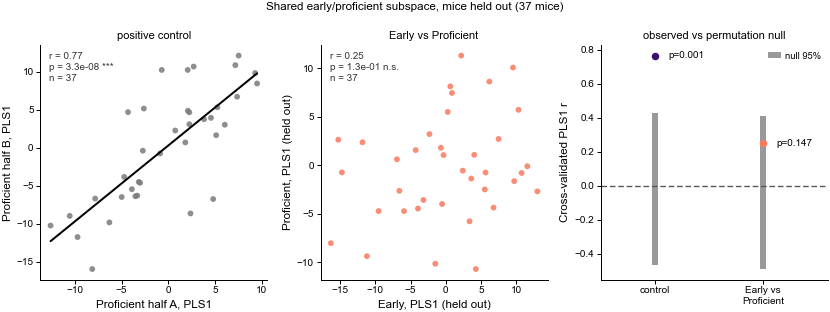

In [9]:
""" FIGURE -- held-out scores, and the CV r against its permutation null. """
ps.reapply()
LW = plt.rcParams['lines.linewidth']
fig, axes = plt.subplots(1, 3, figsize=(ps.SIZES[ps.MODE]['double'][0],
                                        ps.SIZES[ps.MODE]['double'][1] * 0.85))

# (a) the positive control's first component
xs, ys = cv_scores(P_A, P_B, n_comp=3)
ps.corr_panel(axes[0], xs[:, 0], ys[:, 0], color=ps.NEUTRAL,
              xlabel='Proficient half A, PLS1', ylabel='Proficient half B, PLS1')
axes[0].set_title('positive control', fontsize=plt.rcParams['font.size'] * 0.95)

# (b) Early vs Proficient, first component
xs, ys = cv_scores(X_EARLY, X_PROF, n_comp=3)
ps.corr_panel(axes[1], xs[:, 0], ys[:, 0], color=ps.TIMEPOINT['Early'],
              xlabel='Early, PLS1 (held out)', ylabel='Proficient, PLS1 (held out)')
axes[1].set_title('Early vs Proficient', fontsize=plt.rcParams['font.size'] * 0.95)

# (c) observed vs null
ax = axes[2]
for i, (lab, res, col) in enumerate([('control', CTRL, ps.TIMEPOINT['Proficient']),
                                     ('Early vs Prof', MAIN, ps.TIMEPOINT['Early'])]):
    lo, hi = np.percentile(res['null'][:, 0], [2.5, 97.5])
    ax.plot([i, i], [lo, hi], color='0.6', lw=LW * 3, solid_capstyle='butt',
            zorder=1, label='null 95%' if i == 0 else None)
    ax.plot(i, res['r'][0], 'o', color=col, ms=plt.rcParams['lines.markersize'], zorder=2)
    ax.text(i + 0.12, res['r'][0], f'p={res["p"][0]:.3f}', va='center',
            fontsize=plt.rcParams['font.size'] * 0.85)
ax.axhline(0, color='0.35', ls=(0, (4, 2)), lw=LW * 0.7)
ax.set_xticks([0, 1]); ax.set_xticklabels(['control', 'Early vs\nProficient'])
ax.set_xlim(-0.5, 1.6)
ax.set_ylabel('Cross-validated PLS1 r')
ax.set_title('observed vs permutation null', fontsize=plt.rcParams['font.size'] * 0.95)
ax.legend(fontsize=plt.rcParams['font.size'] * 0.8, loc='upper right')

fig.suptitle(f'Shared early/proficient subspace, mice held out ({len(COHORT)} mice)',
             fontsize=plt.rcParams['font.size'])
fig.tight_layout()
ps.savefig(fig, 'sharedsub_pls_early_proficient', svg=True)
plt.show()

wrote figures/sharedsub_pls1_loadings_11-09-2026.png, figures/sharedsub_pls1_loadings_11-09-2026.svg


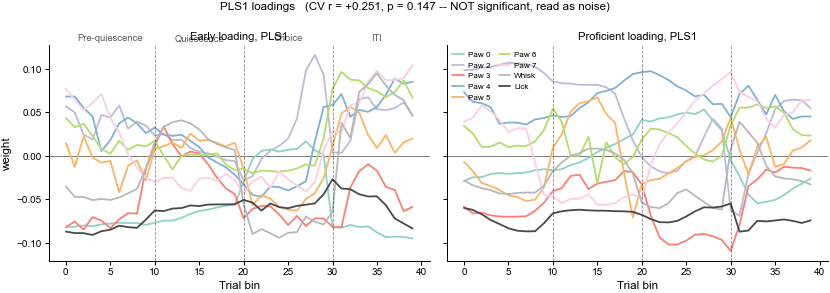

In [10]:
"""
WHAT DOES THE COMPONENT ACTUALLY WEIGHT?
=========================================
Only worth reading if the component is significant -- loadings of a null component are
noise with a shape. Drawn regardless so the shape is on record, with the significance
stated in the title so it cannot be quoted out of context.

The 360 weights are reshaped back to (40 trial bins x 9 features) and shown one line
per feature, which is the same layout syllable_correlations uses.
"""
FULL = PLSCanonical(n_components=3, scale=True, max_iter=1000).fit(X_EARLY, X_PROF)
N_BINS = X_EARLY.shape[1] // len(FEATURE_NAMES)

ps.reapply()
fig, axes = plt.subplots(1, 2, figsize=(ps.SIZES[ps.MODE]['double'][0],
                                        ps.SIZES[ps.MODE]['double'][1] * 0.8),
                         sharey=True)
for ax, W, name in [(axes[0], FULL.x_rotations_[:, 0], 'Early'),
                    (axes[1], FULL.y_rotations_[:, 0], 'Proficient')]:
    G = W.reshape(N_BINS, len(FEATURE_NAMES))
    for j, fn in enumerate(FEATURE_NAMES):
        ax.plot(np.arange(N_BINS), G[:, j], lw=LW * 0.9,
                color=ps.SYLLABLE.get(fn, ps.NEUTRAL), label=fn)
    ps.epoch_lines(ax, N_BINS, label=(ax is axes[0]))
    ps.zero_line(ax)
    ax.set_xlabel('Trial bin')
    ax.set_title(f'{name} loading, PLS1', fontsize=plt.rcParams['font.size'] * 0.95)
axes[0].set_ylabel('weight')
axes[1].legend(fontsize=plt.rcParams['font.size'] * 0.7, ncol=2)
fig.suptitle(f'PLS1 loadings   (CV r = {MAIN["r"][0]:+.3f}, p = {MAIN["p"][0]:.3f}'
             f'{" -- NOT significant, read as noise" if MAIN["p"][0] >= 0.05 else ""})',
             fontsize=plt.rcParams['font.size'])
fig.tight_layout()
ps.savefig(fig, 'sharedsub_pls1_loadings', svg=True)
plt.show()

In [11]:
"""
DIAGNOSTIC -- IS THE EARLY MEASUREMENT RELIABLE AT ALL?   (needs INCLUDE_LATE = True)
=====================================================================================
This is the comparison that decides how to read a null above, and it is the reason
Late is in this notebook at all.

Early has one session per mouse, so there is no way to ask "does this mouse measure
the same on a second early day". The nearest available thing is the LAST TRAINING
session: a different day, the same mice, still inside training. Two outcomes:

  Early<->Late ALSO null    the early vector does not reproduce against ANY other
                            session, so the Early<->Proficient null is about
                            measurement, not about learning.
  Early<->Late works        the early vector is reproducible, and its failure to
                            match Proficient is a real reorganisation.

BUT -- and this is why it is a diagnostic rather than a clean reliability estimate --
Early and Late are also far apart in LEARNING, not just in time. A null between them
is therefore consistent with BOTH "unreliable measurement" AND "the behaviour genuinely
reorganised during training". It does not separate those two. A clean reliability
estimate would need a second early session per mouse, which this dataset does not have.

Late<->Proficient is run alongside as the third rung: if the shared structure grows as
the two timepoints get closer in training, that gradient is itself the finding.
"""
if not INCLUDE_LATE:
    print('INCLUDE_LATE is False -- set it to True in the config cell and re-run '
          'from the build cell to get this diagnostic.')
else:
    COH_EL = sorted(set(DAT['Early'][1]) & set(DAT['Late'][1]))
    EL = cv_test(mouse_matrix('Early', COH_EL), mouse_matrix('Late', COH_EL), n_comp=3)
    report('EARLY vs LATE   (two different training days)', EL, len(COH_EL))
    print()
    COH_LP = sorted(set(DAT['Late'][1]) & set(DAT['Proficient'][1]))
    LP = cv_test(mouse_matrix('Late', COH_LP), mouse_matrix('Proficient', COH_LP), n_comp=3)
    report('LATE vs PROFICIENT', LP, len(COH_LP))
    print()
    print(f'{"pair":26s} {"n":>4s} {"best CV r":>10s} {"max-stat p":>11s}')
    for nm, res, n in [('Early - Late', EL, len(COH_EL)),
                       ('Early - Proficient', MAIN, len(COHORT)),
                       ('Late - Proficient', LP, len(COH_LP))]:
        print(f'{nm:26s} {n:4d} {res["r"].max():+10.3f} {res["p_max"]:11.4f}')

EARLY vs LATE   (two different training days)  (35 mice)
   comp     CV r        p  null mean
      1   +0.023   0.4446     -0.017
      2   +0.020   0.4785     -0.003
      3   -0.008   0.4905     -0.010
  best = component 1, r = +0.023, max-statistic p = 0.8482  <- the corrected p for "best of 3"

LATE vs PROFICIENT  (49 mice)
   comp     CV r        p  null mean
      1   -0.155   0.7303     -0.018
      2   +0.378   0.0260     +0.001
      3   -0.000   0.4795     -0.013
  best = component 2, r = +0.378, max-statistic p = 0.0759  <- the corrected p for "best of 3"

pair                          n  best CV r  max-stat p
Early - Late                 35     +0.023      0.8482
Early - Proficient           37     +0.251      0.3656
Late - Proficient            49     +0.378      0.0759


In [12]:
"""
IS THE WHOLE PATTERN JUST MEASUREMENT NOISE?   (the most important cell here)
=============================================================================
The three-rung table above is NOT ordered by distance in training. Late is closer to
Early than Proficient is, yet Early<->Late is the WEAKEST of the three. So "the
behaviour drifts as training proceeds" does not explain the pattern.

What does order the three is how many sessions each block averages:
    Early       1 session per mouse
    Late        1 session per mouse
    Proficient  3-9 sessions per mouse, averaged
and the two single-session blocks are the pair that scores ~0.

That is the signature of ATTENUATION BY MEASUREMENT ERROR: an observed correlation is
the true one shrunk by the square root of both sides' reliabilities,
    r_obs = r_true * sqrt(rel_X * rel_Y)
so a comparison between two noisy blocks is shrunk twice.

The test below is direct: throw proficient sessions away. Rebuild the proficient
mouse vectors from exactly n sessions and re-run. If the correlation grows with n, the
limiting factor is how well each mouse is MEASURED, not whether individuality persists.

Read the per-rep spread, not just the mean. At n = 1 the estimate is wildly unstable
(that is the point), so the mean alone would be misleading.
"""
N_REPS_ATT = 10

_X, _m, _s = DAT['Proficient']
_sess_of = (pd.DataFrame({'m': _m, 's': _s}).drop_duplicates()
            .groupby('m')['s'].apply(list))

print('EARLY vs PROFICIENT, as a function of how many proficient sessions are averaged')
print(f'{"n sessions":>11s} {"n mice":>7s} {"mean CV r":>10s} {"sd":>7s}   per-rep')
ATT = []
for nsess in [1, 2, 3, 5, None]:
    rs = []
    for rep in range(N_REPS_ATT):
        rng = np.random.default_rng(rep)
        keep, coh = [], []
        for mm in COHORT:
            ss = _sess_of[mm]
            if nsess is not None and len(ss) < nsess:
                continue
            keep += list(ss) if nsess is None else list(rng.choice(ss, nsess, replace=False))
            coh.append(mm)
        Xp_ = mouse_matrix('Proficient', coh, np.isin(_s, keep))
        rs.append(cv_r(mouse_matrix('Early', coh), Xp_, n_comp=1)[0])
    lab = 'all (3-9)' if nsess is None else str(nsess)
    ATT.append(dict(n=lab, mice=len(coh), mean=np.mean(rs), sd=np.std(rs)))
    print(f'{lab:>11s} {len(coh):7d} {np.mean(rs):+10.3f} {np.std(rs):7.3f}   '
          f'{np.round(rs, 2)}')

print('\nThe same knob on the POSITIVE CONTROL (proficient vs proficient), which puts a')
print('number on how reliable ONE session is -- there the true correlation is 1 by')
print('construction, so the observed value IS the reliability.')
print(f'{"n per half":>11s} {"n mice":>7s} {"mean CV r":>10s}')
for nsess in [1, 2, 3]:
    rs = []
    for rep in range(N_REPS_ATT):
        rng = np.random.default_rng(rep)
        ka, kb, coh = [], [], []
        for mm in COHORT:
            ss = list(rng.permutation(_sess_of[mm]))
            if len(ss) < 2 * nsess:
                continue
            ka += ss[:nsess]; kb += ss[nsess:2 * nsess]; coh.append(mm)
        rs.append(cv_r(mouse_matrix('Proficient', coh, np.isin(_s, ka)),
                       mouse_matrix('Proficient', coh, np.isin(_s, kb)), n_comp=1)[0])
    print(f'{nsess:>11d} {len(coh):7d} {np.mean(rs):+10.3f}')

print("""
WHAT THIS MEANS
  The binding constraint on this question is SESSIONS PER MOUSE AT EARLY, not mice.
  Early contributes one session and cannot be averaged, so every comparison involving
  it is attenuated by that single session's unreliability -- and no amount of extra
  mice removes that shrinkage, it only tightens the confidence interval around an
  already-shrunk number.

  So the Early<->Proficient null should NOT be read as "individuality is absent early"
  nor as "learning reorganised the behaviour". It should be read as "this dataset
  cannot tell", with the fix being two or three early-training sessions per mouse
  rather than a larger cohort.""")

EARLY vs PROFICIENT, as a function of how many proficient sessions are averaged
 n sessions  n mice  mean CV r      sd   per-rep
          1      37     +0.043   0.223   [ 0.33 -0.15  0.05 -0.1  -0.08  0.09 -0.36  0.25  0.4  -0.01]
          2      37     +0.227   0.047   [0.19 0.22 0.25 0.18 0.15 0.3  0.24 0.19 0.27 0.28]
          3      37     +0.250   0.030   [0.27 0.25 0.25 0.26 0.22 0.29 0.18 0.29 0.23 0.26]
          5      11     +0.403   0.100   [0.55 0.49 0.41 0.43 0.26 0.28 0.38 0.43 0.27 0.53]
  all (3-9)      37     +0.251   0.000   [0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25]

The same knob on the POSITIVE CONTROL (proficient vs proficient), which puts a
number on how reliable ONE session is -- there the true correlation is 1 by
construction, so the observed value IS the reliability.
 n per half  n mice  mean CV r
          1      37     +0.646
          2      22     +0.644
          3       7     +0.941

WHAT THIS MEANS
  The binding constraint on this question i

## How to read this notebook

**The positive control comes first.** Proficient half A vs half B shows a strong,
significant held-out correlation (PLS r ≈ 0.77–0.82, CCA ≈ 0.91–0.94). The machinery
can detect a shared subspace when one exists, so the nulls below are real nulls.

**The null is zero here**, because mice are held out. That is the main gain over
`early_lda_alignment.ipynb`, where 37 mice × 3 dimensions gave a chance canonical
r ≈ 0.4 for free. A CV r of 0.25 against a zero null is a visible effect that misses
significance — a different situation from sitting exactly on chance.

**Quote the max-statistic p** whenever more than one component was inspected.

### The headline

Early ↔ Proficient does not reach significance (PLS best r = 0.25, max-stat p = 0.37;
CCA best r = 0.43, max-stat p = 0.07). But the last cell shows that this number is
**governed by how many proficient sessions are averaged**, collapsing to ≈ 0 when only
one session is used — which is exactly the value Early ↔ Late returns, itself a
one-session-vs-one-session comparison.

So the three-rung table must **not** be read as a drift gradient. It is not ordered by
distance in training: Late is nearer to Early than Proficient is, yet Early ↔ Late is
the weakest pair. It is ordered by sessions averaged, which is attenuation by
measurement error.

### What this licenses you to say

| claim | supported? |
|---|---|
| "the top 3 LDA axes are not shared between Early and Proficient" | yes — `early_lda_alignment.ipynb` |
| "no large linear shared subspace is detectable at n = 37" | yes |
| "individuality is absent at early training" | **no** |
| "learning reorganised the behaviour" | **no** |
| "this dataset cannot resolve the question" | yes — and this is the honest headline |

### The fix is sessions, not mice

Early contributes one session per mouse and cannot be averaged, so every comparison
involving it is shrunk by that session's unreliability. More mice tighten the interval
around an already-shrunk estimate; they do not undo the shrinkage. Two or three
early-training sessions per mouse would. That is the concrete experimental
recommendation this analysis produces, and it is arguably worth more than the p-values.

### Still uncontrolled

Age, weight, sex, rig. If a shared subspace ever does come out significant, check that
it survives regressing those out — otherwise the "individuality" may be body size.